In [50]:
# Ignore a bunch of deprecation warnings
import warnings
warnings.filterwarnings("ignore")

import copy
import os
import time

import crepe
import ddsp
import ddsp.training
from ddsp.training.postprocessing import (
    detect_notes, fit_quantile_transform
)
from ddsp.training import (data, decoders, encoders, models, preprocessing, 
                           train_util, trainers)
import gin
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pickle
import tensorflow.compat.v2 as tf
import tensorflow_datasets as tfds
import tensorflow as tf

print('Done!')
     

Done!


In [43]:
# Plot spectrograms
def plot_spectrogram(waveform, title):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(waveform, n_fft=1024)), ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [44]:
# Step 1: Load the full NSynth TFDS dataset (train split)
provider = data.NSynthTfds(split='train')
dataset = provider.get_dataset(shuffle=False)

# Step 2: Filter for instrument_family == 2 (Guitar)
def filter_guitar(example):
    return tf.equal(example['instrument_family'], 2)

filtered_dataset = dataset.filter(filter_guitar)

# Step 3: Batch and prefetch
batched_dataset = filtered_dataset.take(1).batch(1).repeat().prefetch(tf.data.AUTOTUNE)

# Step 4: Get a batch of 10 examples
batch = next(iter(batched_dataset))
audio = batch['audio']
n_samples = audio.shape[1]

# Optional: print keys and shapes
for k, v in batch.items():
    print(f"{k}: {v.shape}")
    
print(f"Number of Samples: {n_samples}")

audio: (1, 64000)
f0_hz: (1, 1000)
f0_confidence: (1, 1000)
loudness_db: (1, 1000)
pitch: (1,)
instrument_source: (1,)
instrument_family: (1,)
instrument: (1,)
Number of Samples: 64000


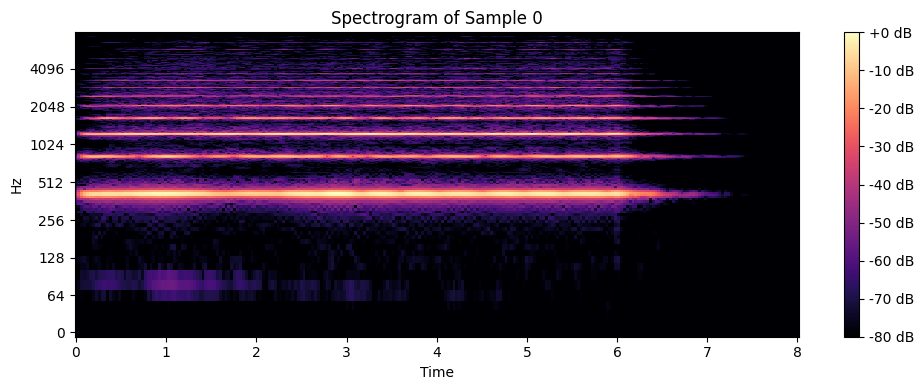

In [45]:
import soundfile as sf
plot_spectrogram(audio[0].numpy(), title="Spectrogram of Sample 0")
# sf.write("batch_example.wav", audio.numpy()[0], 16000)

In [46]:
strategy = train_util.get_strategy()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


In [60]:
TIME_STEPS = 1000

# Create Neural Networks.
preprocessor = preprocessing.F0LoudnessPreprocessor(time_steps=TIME_STEPS)

decoder = decoders.RnnFcDecoder(rnn_channels = 256,
                                rnn_type = 'gru',
                                ch = 256,
                                layers_per_stack = 1,
                                input_keys = ('ld_scaled', 'f0_scaled'),
                                output_splits = (('amps', 1),
                                                 ('harmonic_distribution', 45),
                                                 ('noise_magnitudes', 45)))

# Create Processors.
harmonic = ddsp.synths.Harmonic(n_samples=n_samples, 
                                sample_rate=16000,
                                name='harmonic')

noise = ddsp.synths.FilteredNoise(window_size=0,
                                  initial_bias=-10.0,
                                  name='noise')
add = ddsp.processors.Add(name='add')

# Create ProcessorGroup.
dag = [(harmonic, ['amps', 'harmonic_distribution', 'f0_hz']),
       (noise, ['noise_magnitudes']),
       (add, ['noise/signal', 'harmonic/signal'])]

processor_group = ddsp.processors.ProcessorGroup(dag=dag,
                                                 name='processor_group')


# Loss_functions
spectral_loss = ddsp.losses.SpectralLoss(loss_type='L1',
                                         mag_weight=1.0,
                                         logmag_weight=1.0)

with strategy.scope():
  # Put it together in a model.
  model = models.Autoencoder(preprocessor=preprocessor,
                             encoder=None,
                             decoder=decoder,
                             processor_group=processor_group,
                             losses=[spectral_loss])
  trainer = trainers.Trainer(model, strategy, learning_rate=1e-3)

In [61]:
# Build model, easiest to just run forward pass.
dataset = trainer.distribute_dataset(dataset)
trainer.build(next(iter(dataset)))

2025-05-13 01:09:41.768270: W tensorflow/core/framework/dataset.cc:769] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


Model: "autoencoder_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 f0_loudness_preprocessor_13  multiple                 0         
  (F0LoudnessPreprocessor)                                       
                                                                 
 rnn_fc_decoder_13 (RnnFcDec  multiple                 814171    
 oder)                                                           
                                                                 
 processor_group (ProcessorG  multiple                 0         
 roup)                                                           
                                                                 
 spectral_loss (SpectralLoss  multiple                 0         
 )                                                               
                                                                 
Total params: 814,171
Trainable params: 814,171
Non-

In [62]:
dataset_iter = iter(dataset)

for i in range(50):
  losses = trainer.train_step(dataset_iter)
  res_str = 'step: {}\t'.format(i)
  for k, v in losses.items():
    res_str += '{}: {:.2f}\t'.format(k, v)
  print(res_str)

2025-05-13 01:11:16.769871: W tensorflow/core/framework/dataset.cc:769] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


step: 0	spectral_loss: 21.28	total_loss: 21.28	
step: 1	spectral_loss: 22.71	total_loss: 22.71	
step: 2	spectral_loss: 29.85	total_loss: 29.85	
step: 3	spectral_loss: 26.40	total_loss: 26.40	
step: 4	spectral_loss: 22.41	total_loss: 22.41	
step: 5	spectral_loss: 17.25	total_loss: 17.25	
step: 6	spectral_loss: 19.24	total_loss: 19.24	
step: 7	spectral_loss: 26.49	total_loss: 26.49	
step: 8	spectral_loss: 37.43	total_loss: 37.43	
step: 9	spectral_loss: 21.39	total_loss: 21.39	
step: 10	spectral_loss: 22.22	total_loss: 22.22	
step: 11	spectral_loss: 16.18	total_loss: 16.18	
step: 12	spectral_loss: 20.43	total_loss: 20.43	
step: 13	spectral_loss: 18.44	total_loss: 18.44	
step: 14	spectral_loss: 32.91	total_loss: 32.91	
step: 15	spectral_loss: 25.04	total_loss: 25.04	
step: 16	spectral_loss: 17.58	total_loss: 17.58	
step: 17	spectral_loss: 23.92	total_loss: 23.92	
step: 18	spectral_loss: 27.10	total_loss: 27.10	
step: 19	spectral_loss: 19.24	total_loss: 19.24	
step: 20	spectral_loss: 15.82	

In [63]:
# Run a batch of predictions.
start_time = time.time()
controls =  model(next(dataset_iter))
print('Prediction took %.1f seconds' % (time.time() - start_time))

Prediction took 0.9 seconds


In [72]:
# 1) Run the model to get the full controls dict
controls = model(next(dataset_iter))

# 2) Make a linear amplitude envelope from the true dB loudness
amplitude_envelope = ddsp.core.db_to_amplitude(controls['loudness_db'])

# 3) Apply it to your relative 'amps' so they pick up the correct absolute gain
controls['amps'] = controls['amps'] * amplitude_envelope[..., None]

# 4) Now synthesize
audio_gen = model.get_audio_from_outputs(controls)


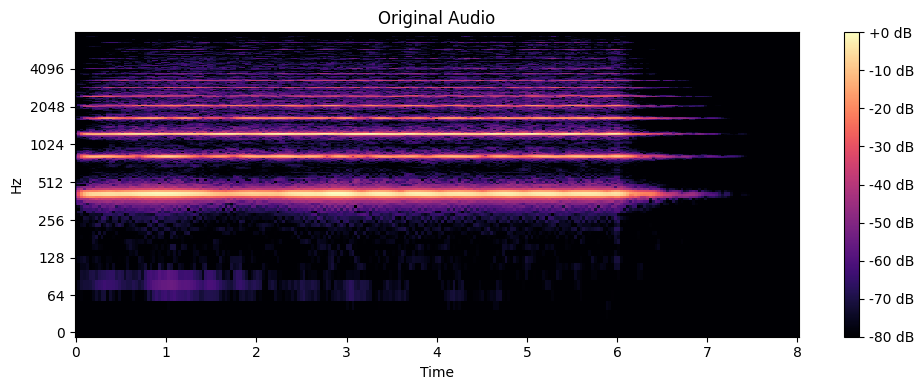

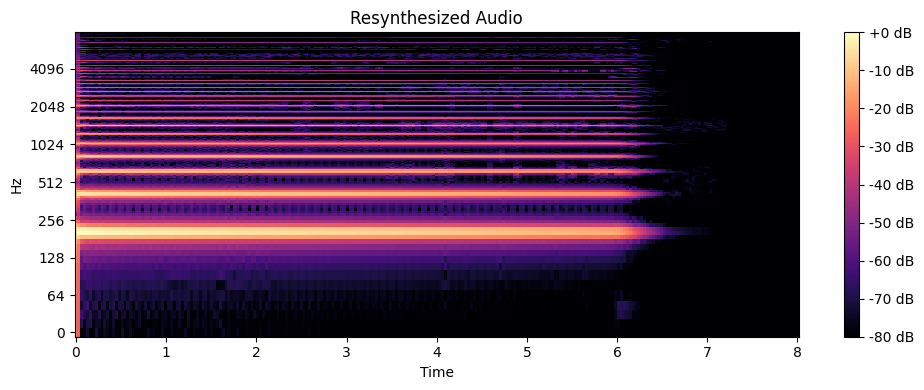

In [ ]:
# Save audio to current directory
sf.write("original.wav", audio.numpy()[0], 16000)
sf.write("resynthesized.wav", audio_gen.numpy()[0], 16000)
plot_spectrogram(audio.numpy()[0], "Original Audio")
plot_spectrogram(audio_gen.numpy()[0], "Resynthesized Audio")

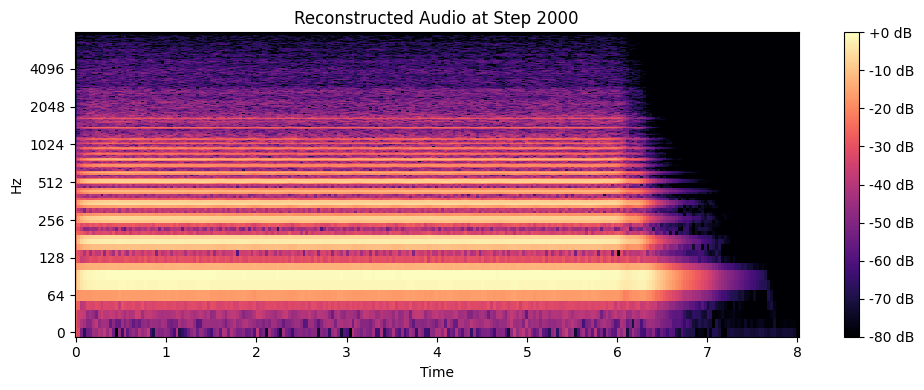

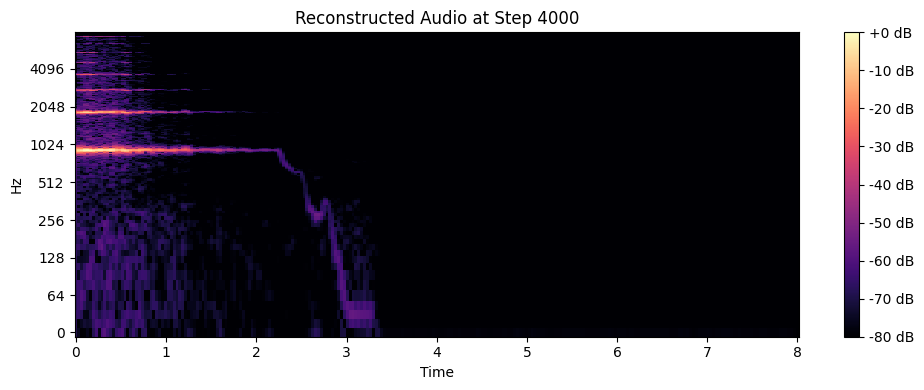

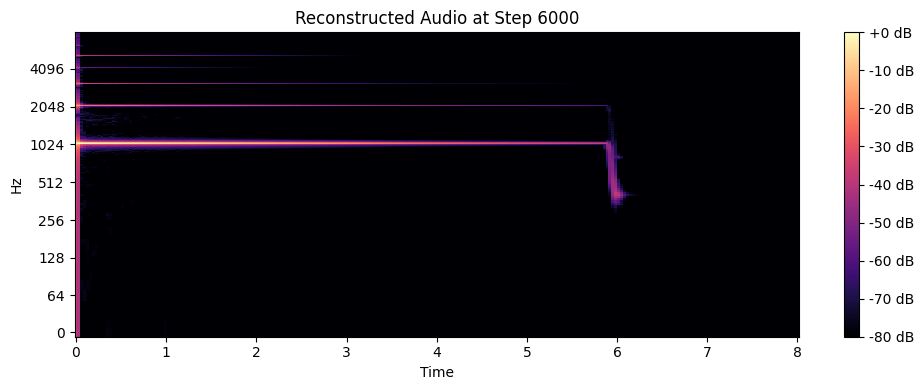

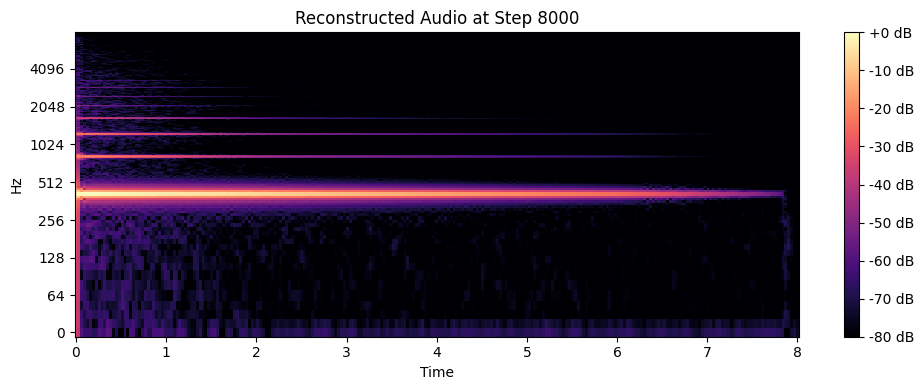

In [76]:
import soundfile as sf

for step in [2000, 4000, 6000, 8000]:
    audio_recon, sr = sf.read(f"recon_step{step}.wav")
    plot_spectrogram(audio_recon, f"Reconstructed Audio at Step {step}")


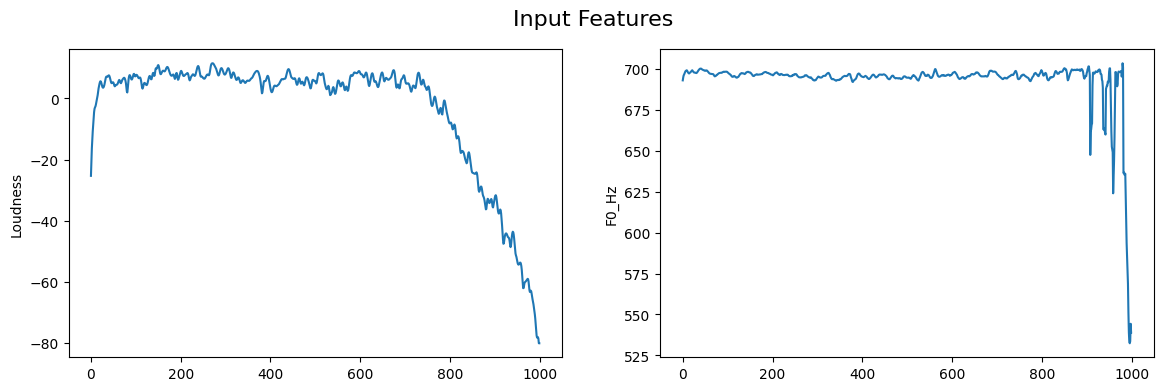

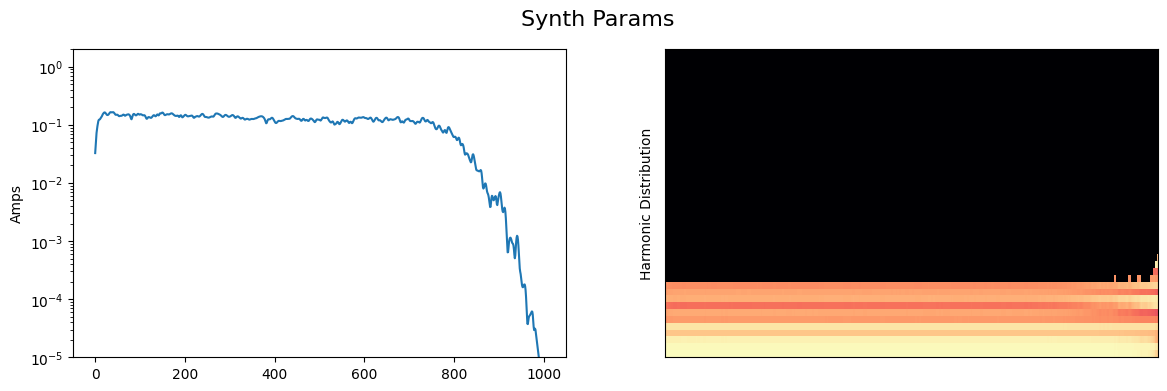

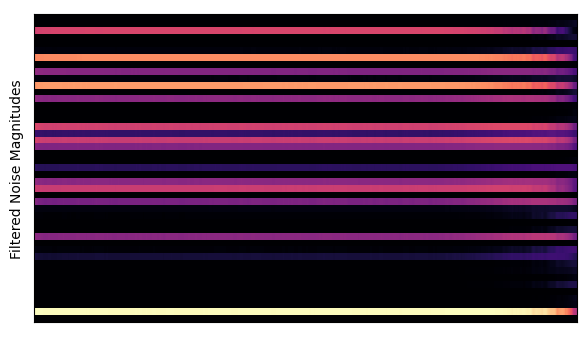

In [12]:
batch_idx = 0
get = lambda key: ddsp.core.nested_lookup(key, controls)[batch_idx]

amps = get('harmonic/controls/amplitudes')
harmonic_distribution = get('harmonic/controls/harmonic_distribution')
noise_magnitudes = get('noise/controls/magnitudes')
f0_hz = get('f0_hz')
loudness = get('loudness_db')

audio_noise = get('noise/signal')

f, ax = plt.subplots(1, 2, figsize=(14, 4))
f.suptitle('Input Features', fontsize=16)
ax[0].plot(loudness)
ax[0].set_ylabel('Loudness')
ax[1].plot(f0_hz)
ax[1].set_ylabel('F0_Hz')

f, ax = plt.subplots(1, 2, figsize=(14, 4))
f.suptitle('Synth Params', fontsize=16)
ax[0].semilogy(amps)
ax[0].set_ylabel('Amps')
ax[0].set_ylim(1e-5, 2)
# ax[0].semilogy(harmonic_distribution)
ax[1].matshow(np.rot90(np.log10(harmonic_distribution + 1e-6)),
              cmap=plt.cm.magma, 
              aspect='auto')
ax[1].set_ylabel('Harmonic Distribution')
ax[1].set_xticks([])
_ = ax[1].set_yticks([])

f, ax = plt.subplots(1, 1, figsize=(7, 4))
# f.suptitle('Filtered Noise Params', fontsize=16)
ax.matshow(np.rot90(np.log10(noise_magnitudes + 1e-6)), 
           cmap=plt.cm.magma, 
           aspect='auto')
ax.set_ylabel('Filtered Noise Magnitudes')
ax.set_xticks([])
_ = ax.set_yticks([])

In [33]:
import scipy.linalg

# Performance Analysis Helper Functions:
def mag_spectrogram(y, sr, n_fft=1024, hop_length=256):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
    return np.abs(S)

def log_spectral_distance(y_true, y_pred, sr, n_fft=1024, hop_length=256, eps=1e-8):
    S_true = mag_spectrogram(y_true, sr, n_fft, hop_length)
    S_pred = mag_spectrogram(y_pred, sr, n_fft, hop_length)
    # convert to log10 scale
    L_true = 20 * np.log10(S_true + eps)
    L_pred = 20 * np.log10(S_pred + eps)

    diff2 = (L_true - L_pred) ** 2
    lsd_frames = np.sqrt(np.mean(diff2, axis=0))
    return np.mean(lsd_frames)

def spectral_convergence(y_true, y_pred, sr, n_fft=1024, hop_length=256):
    S_true = mag_spectrogram(y_true, sr, n_fft, hop_length)
    S_pred = mag_spectrogram(y_pred, sr, n_fft, hop_length)
    num = np.linalg.norm(S_true - S_pred, ord='fro')
    den = np.linalg.norm(S_true, ord='fro') + 1e-8
    return num / den

def snr_db(y_true, y_pred, eps=1e-8):
    noise = y_true - y_pred
    power_signal = np.sum(y_true ** 2)
    power_noise  = np.sum(noise ** 2) + eps
    return 10 * np.log10(power_signal / power_noise)

def embed_mel(waveform, sr=16000, n_mels=64, n_fft=1024, hop_length=256):
    S = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=1.0
    )
    return S.T      # shape (T, n_mels)

def compute_statistics(embeddings_list):
    all_embs = np.vstack(embeddings_list)
    mu    = np.mean(all_embs, axis=0)
    sigma = np.cov(all_embs, rowvar=False)
    return mu, sigma

def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    mu_diff = mu1 - mu2
    covmean, _ = scipy.linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1 + offset) @ (sigma2 + offset))
    # drop tiny imaginary parts
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return (mu_diff @ mu_diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def compute_fad_mel(y_true_list, y_pred_list, sr=16000):
    # allow passing single arrays
    if isinstance(y_true_list, np.ndarray):
        y_true_list = [y_true_list]
    if isinstance(y_pred_list, np.ndarray):
        y_pred_list = [y_pred_list]

    true_embs = [embed_mel(y, sr) for y in y_true_list]
    pred_embs = [embed_mel(y, sr) for y in y_pred_list]
    mu1, sigma1 = compute_statistics(true_embs)
    mu2, sigma2 = compute_statistics(pred_embs)
    return frechet_distance(mu1, sigma1, mu2, sigma2)

In [34]:
y_true = audio.numpy().reshape(-1)
y_pred = audio_gen.numpy().reshape(-1)

# 2. Compute reconstruction-error metrics
lsd_value = log_spectral_distance(y_true, y_pred, sr=16000, n_fft=1024, hop_length=256)
sc_value  = spectral_convergence(y_true, y_pred, sr=16000, n_fft=1024, hop_length=256)
snr_value = snr_db(y_true, y_pred)
fad_score = compute_fad_mel(y_true, y_pred, sr=16000)


# 3. Print
print("PERFORMANCE METRICS")
print("==========================================================\n")
print(f"Log-Spectral Distance (LSD):      {lsd_value:.3f} dB")
print(f"Spectral Convergence:             {sc_value:.5f}")
print(f"Signal-to-Noise Ratio (SNR):      {snr_value:.2f} dB")
print(f"Frechet Audio Distance (FAD):     {fad_score:.4f}")
print("==========================================================\n")

PERFORMANCE METRICS

Log-Spectral Distance (LSD):      30.052 dB
Spectral Convergence:             1.00443
Signal-to-Noise Ratio (SNR):      -0.12 dB
Frechet Audio Distance (FAD):     6.2396



In [36]:
trainer.save("./reconstruction_checkpoint")

In [68]:
from tqdm import tqdm
import os

n_steps     = 10_000            
eval_every  = 2_000             
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

for step in tqdm(range(n_steps), desc='Training'):
  losses = trainer.train_step(dataset_iter)

  if step % 100 == 0:
    print(f"Step {step:5d}  spectral_loss={losses['spectral_loss']:.2f}")

  if step > 0 and step % eval_every == 0:
    # 1) Save model weights
    model.save_weights(f"{checkpoint_dir}/step_{step}.ckpt")
    # 2) Do a quick forward pass + loudness inversion
    controls = model(next(dataset_iter))
    loud_db = controls['loudness_db']
    env     = ddsp.core.db_to_amplitude(loud_db)
    controls['amps'] *= env[..., None]
    audio_gen = model.get_audio_from_outputs(controls)
    sf.write(f"recon_step{step}.wav",
             audio_gen.numpy()[0],
             SAMPLE_RATE)
    print(f"  ↳ Saved checkpoint and recon at step {step}")


Training:   0%|          | 1/10000 [00:00<51:02,  3.26it/s]

Step     0  spectral_loss=11.61


Training:   0%|          | 7/10000 [00:02<58:43,  2.84it/s]


KeyboardInterrupt: 